In [12]:
import os
print(os.getcwd())
print(os.listdir())

f:\Workspace\PYTHON\Projects\FeedbackAnalysis\notebooks
['acronyms_dictionary.txt', 'baseline_model.ipynb', 'kiem_tra_dau_tieng_viet.csv', 'main_PhoBERT_sentiment_Kaggle.ipynb', 'main_PhoBERT_topic_Kaggle.ipynb', 'PhoBERT_Data_Preprocessing.ipynb', 'PhoBERT_Inference.ipynb', 'vncorenlp']


In [13]:
import sys
!uv pip install --python {sys.executable} --upgrade transformers accelerate huggingface_hub

Using Python 3.11.15 environment at: f:\Workspace\PYTHON\Projects\FeedbackAnalysis\.venv
Resolved 37 packages in 809ms
Checked 37 packages in 5ms


In [14]:
import os
import json

base_dir = os.path.dirname(os.getcwd()) 
path = os.path.join(base_dir, "models", "sentiment_model")
config_path = os.path.join(path, "config.json")
print(f"Đường dẫn config đang trỏ tới: {config_path}")

print(f"Kiểm tra file: {config_path}")
print(f"File có tồn tại không? {os.path.exists(config_path)}")

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        data = json.load(f)
        print("Nội dung config.json:")
        print(json.dumps(data, indent=2))
        print(f"\nModel type tìm thấy: {data.get('model_type', 'KHÔNG CÓ model_type')}")

Đường dẫn config đang trỏ tới: f:\Workspace\PYTHON\Projects\FeedbackAnalysis\models\sentiment_model\config.json
Kiểm tra file: f:\Workspace\PYTHON\Projects\FeedbackAnalysis\models\sentiment_model\config.json
File có tồn tại không? True
Nội dung config.json:
{
  "add_cross_attention": false,
  "architectures": [
    "RobertaForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "2",
    "1": "0",
    "2": "1"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "0": 1,
    "1": 2,
    "2": 0
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 258,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true

In [15]:
import os
import torch
from transformers import AutoTokenizer, RobertaForSequenceClassification
import re
from underthesea import text_normalize

# =====================================================================
# 1. HỆ THỐNG TIỀN XỬ LÝ (Áp dụng cho câu nhập vào)
# =====================================================================
# Lùi ra 1 cấp từ thư mục notebooks
base_dir = os.path.dirname(os.getcwd()) 
dict_path = os.path.join(base_dir, "acronyms_dictionary.txt")

def load_acronyms(file_path):
    acronyms_dict = {}
    if os.path.exists(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#'): continue
                if '=' in line:
                    key, value = line.split('=', 1)
                    acronyms_dict[key.strip().lower()] = value.strip().lower()
    return acronyms_dict

ACRONYMS_DICT = load_acronyms(dict_path)

# Hàm làm sạch chuyên biệt
def clean_sentence_for_test(text):
    if not isinstance(text, str) or str(text).strip() == "": return ""
    text = str(text).lower()
    text = text_normalize(text)
    
    if ACRONYMS_DICT:
        for shortcut, full_word in ACRONYMS_DICT.items():
            if re.match(r'^\w+$', shortcut, flags=re.UNICODE):
                text = re.sub(r'\b' + shortcut + r'\b', full_word, text)
            else:
                text = text.replace(shortcut, full_word)
                
    try:
        # Nhớ nạp rdrsegmenter vào RAM trước đó nhé
        sentences = rdrsegmenter.word_segment(text)
        text_segmented = sentences[0] if sentences else text
    except Exception:
        text_segmented = text
        
    return text_segmented

# =====================================================================
# 2. KHỞI TẠO BỘ NÃO KÉP (Nạp Model vào RAM)
# =====================================================================
print("⏳ Đang nạp hệ thống phân tích kép...")

# Tokenizer dùng chung
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

# Đường dẫn an toàn bằng os.path.join (Chỏ vào thư mục con best_phobert_model)
path_sentiment_model = os.path.join(base_dir, "models/sentiment_model")
path_topic_model = os.path.join(base_dir, "models/topic_model")

# Kiểm tra chặn lỗi:
if not os.path.exists(os.path.join(path_sentiment_model, "config.json")):
    raise FileNotFoundError(f"❌ Không tìm thấy config.json tại: {path_sentiment_model}")
if not os.path.exists(os.path.join(path_topic_model, "config.json")):
    raise FileNotFoundError(f"❌ Không tìm thấy config.json tại: {path_topic_model}")

# Nạp Não 1
model_sentiment = RobertaForSequenceClassification.from_pretrained(path_sentiment_model, local_files_only=True)
model_sentiment.eval()

# Nạp Não 2
model_topic = RobertaForSequenceClassification.from_pretrained(path_topic_model, local_files_only=True)
model_topic.eval()

print("✅ Hệ thống đã sẵn sàng 100%!")

# =====================================================================
# 3. HÀM ĐIỀU PHỐI CHÍNH (The Facade)
# =====================================================================
def analyze_feedback(text):
    clean_text = clean_sentence_for_test(text)
    inputs = tokenizer(clean_text, return_tensors="pt", padding=True, truncation=True, max_length=256)
    
    with torch.no_grad():
        output_sentiment = model_sentiment(**inputs)
        pred_sentiment_idx = torch.argmax(output_sentiment.logits, dim=1).item()
        label_sentiment = model_sentiment.config.id2label[pred_sentiment_idx]
        
        output_topic = model_topic(**inputs)
        pred_topic_idx = torch.argmax(output_topic.logits, dim=1).item()
        label_topic = model_topic.config.id2label[pred_topic_idx]
        
    return {
        "Raw": text,
        "Cleaned": clean_text,
        "Topic": label_topic,
        "Sentiment": label_sentiment
    }

⏳ Đang nạp hệ thống phân tích kép...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3765.19it/s]

✅ Hệ thống đã sẵn sàng 100%!


In [16]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score
from tqdm.auto import tqdm
import os

# =====================================================================
# 4. CHẤM ĐIỂM MÔ HÌNH TRÊN TẬP TEST
# =====================================================================

# Sử dụng lại base_dir đã khai báo ở Cell 2
# Trỏ đến: FeedbackAnalysis/data/processed/test_clean_PhoBERT.csv
test_csv_path = os.path.join(base_dir, "data", "processed", "test_clean_PhoBERT.csv")

# Zero Trust: Kiểm tra xem có thấy file chưa trước khi chạy
print(f"🔍 Đang kiểm tra file Test tại: {test_csv_path}")
if not os.path.exists(test_csv_path):
    raise FileNotFoundError("❌ Không tìm thấy file test. Hãy kiểm tra lại tên file hoặc thư mục!")
else:
    print("✅ Đã chốt tọa độ file Test. Sẵn sàng lên thớt!\n")

true_topics, pred_topics = [], []
true_sentiments, pred_sentiments = [], []

def evaluate_model_on_test_set(file_path):
    global true_topics, pred_topics, true_sentiments, pred_sentiments
    print("📥 Đang nạp dữ liệu Test...")
    df_test = pd.read_csv(file_path)
    
    texts = df_test['clean_text_PhoBERT'].tolist()
    true_topics = df_test['topic'].tolist() 
    true_sentiments = df_test['sentiment'].tolist()
    
    pred_topics = []
    pred_sentiments = []
    
    print(f"🚀 Bắt đầu chấm điểm {len(texts)} bài thi...")
    for text in tqdm(texts):
        result = analyze_feedback(text)
        # Ép về int để khớp với true_topics
        pred_topics.append(int(result['Topic'])) 
        pred_sentiments.append(int(result['Sentiment']))
        
    print("\n" + "="*55)
    print("🏆 BÁO CÁO THÀNH TÍCH CHỦ ĐỀ (TOPIC)")
    print("="*55)
    print(classification_report(true_topics, pred_topics))
    print(f"✅ Accuracy: {accuracy_score(true_topics, pred_topics):.4f}")

    print("\n" + "="*55)
    print("🏆 BÁO CÁO THÀNH TÍCH CẢM XÚC (SENTIMENT)")
    print("="*55)
    print(classification_report(true_sentiments, pred_sentiments))
    print(f"✅ Accuracy: {accuracy_score(true_sentiments, pred_sentiments):.4f}")

# Gọi hàm để bắt đầu chạy
evaluate_model_on_test_set(test_csv_path)

🔍 Đang kiểm tra file Test tại: f:\Workspace\PYTHON\Projects\FeedbackAnalysis\data\processed\test_clean_PhoBERT.csv
✅ Đã chốt tọa độ file Test. Sẵn sàng lên thớt!

📥 Đang nạp dữ liệu Test...
🚀 Bắt đầu chấm điểm 3166 bài thi...


100%|██████████| 3166/3166 [13:43<00:00,  3.85it/s]   



🏆 BÁO CÁO THÀNH TÍCH CHỦ ĐỀ (TOPIC)
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2290
           1       0.77      0.80      0.78       572
           2       0.94      0.94      0.94       145
           3       0.62      0.47      0.53       159

    accuracy                           0.89      3166
   macro avg       0.82      0.79      0.80      3166
weighted avg       0.89      0.89      0.89      3166

✅ Accuracy: 0.8936

🏆 BÁO CÁO THÀNH TÍCH CẢM XÚC (SENTIMENT)
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      1409
           1       0.73      0.46      0.56       167
           2       0.95      0.96      0.96      1590

    accuracy                           0.94      3166
   macro avg       0.87      0.80      0.83      3166
weighted avg       0.94      0.94      0.94      3166

✅ Accuracy: 0.9397


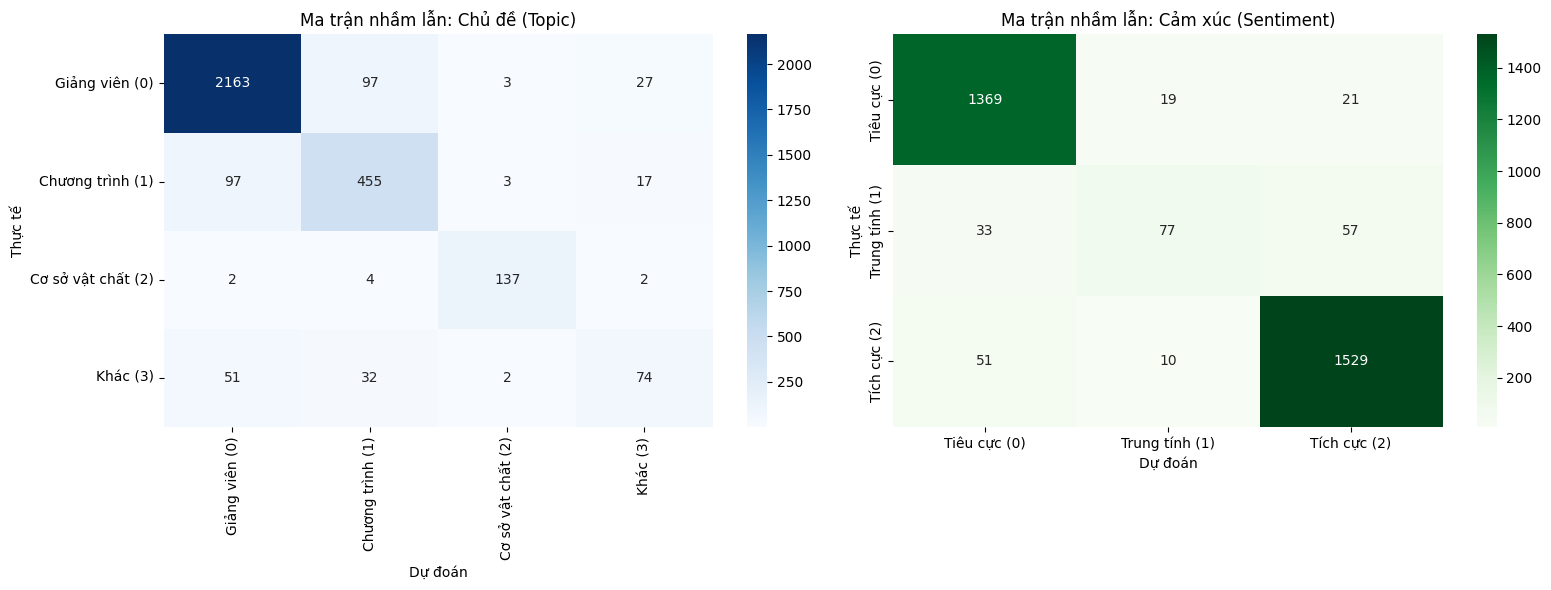

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# 1. ĐỊNH NGHĨA TÊN NHÃN CỦA BẠN (Sửa tên trong ngoặc theo đúng tập dữ liệu)
topic_labels = ['Giảng viên (0)', 'Chương trình (1)', 'Cơ sở vật chất (2)','Khác (3)']
sentiment_labels = ['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']

# 2. VẼ BIỂU ĐỒ VỚI TÊN NHÃN
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Ma trận cho Topic
sns.heatmap(confusion_matrix(true_topics, pred_topics), 
            annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=topic_labels, yticklabels=topic_labels)
ax[0].set_title('Ma trận nhầm lẫn: Chủ đề (Topic)')
ax[0].set_xlabel('Dự đoán')
ax[0].set_ylabel('Thực tế')

# Ma trận cho Sentiment
sns.heatmap(confusion_matrix(true_sentiments, pred_sentiments), 
            annot=True, fmt='d', cmap='Greens', ax=ax[1],
            xticklabels=sentiment_labels, yticklabels=sentiment_labels)
ax[1].set_title('Ma trận nhầm lẫn: Cảm xúc (Sentiment)')
ax[1].set_xlabel('Dự đoán')
ax[1].set_ylabel('Thực tế')

plt.tight_layout()
plt.show()

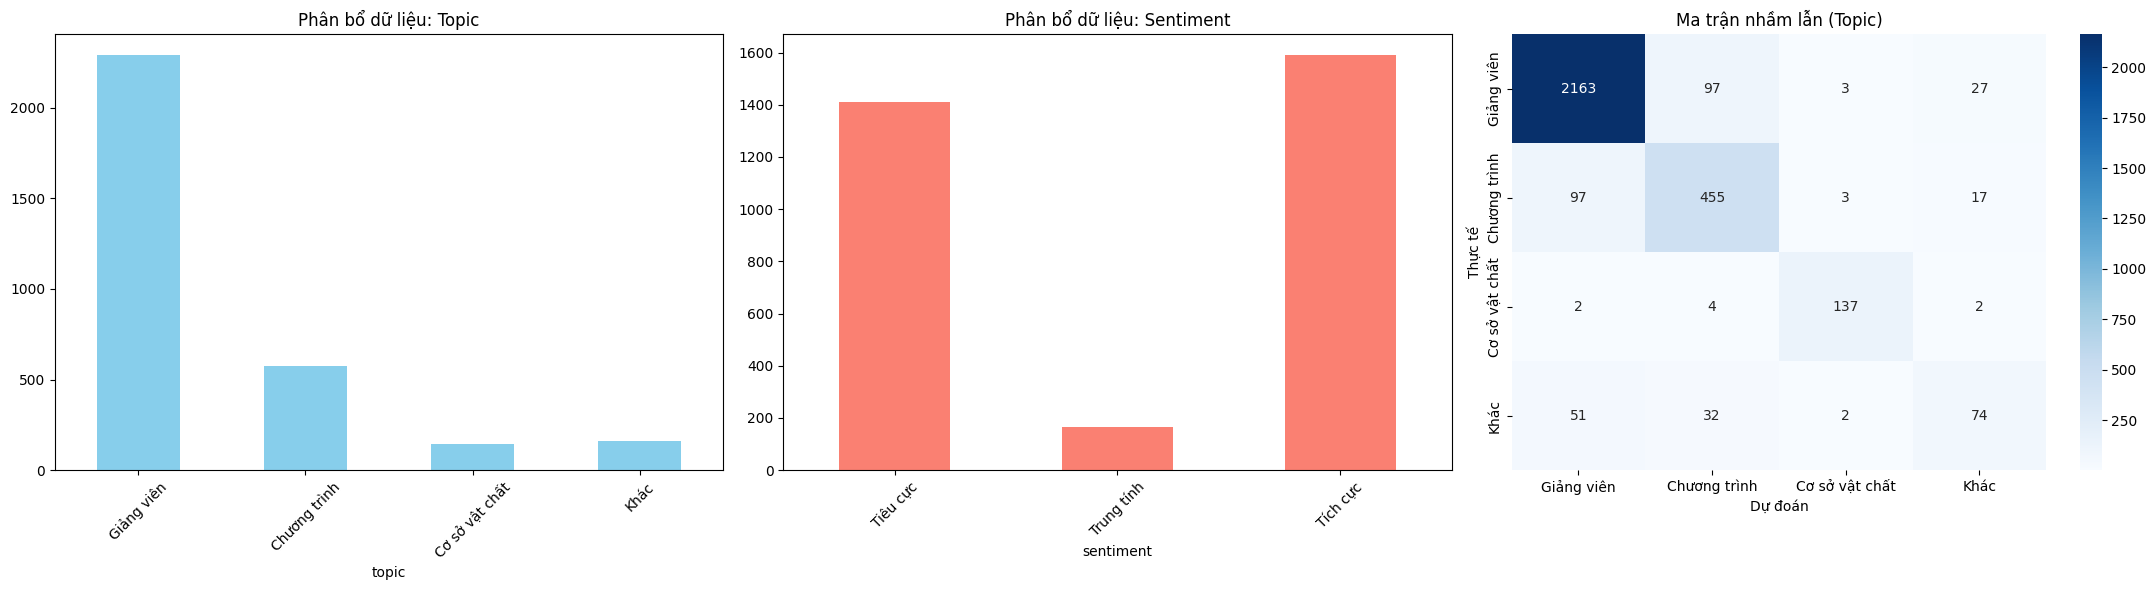

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# 1. ĐỊNH NGHĨA NHÃN
topic_labels = ['Giảng viên', 'Chương trình', 'Cơ sở vật chất', 'Khác'] 
sentiment_labels = ['Tiêu cực', 'Trung tính', 'Tích cực']

# 2. VẼ BIỂU ĐỒ
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# A. Phân bổ nhãn Topic
df_test['topic'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Phân bổ dữ liệu: Topic')
ax[0].set_xticklabels(topic_labels, rotation=45)

# B. Phân bổ nhãn Sentiment
df_test['sentiment'].value_counts().sort_index().plot(kind='bar', ax=ax[1], color='salmon')
ax[1].set_title('Phân bổ dữ liệu: Sentiment')
ax[1].set_xticklabels(sentiment_labels, rotation=45)

# C. Ma trận nhầm lẫn (Confusion Matrix) với nhãn chữ
cm_topic = confusion_matrix(true_topics, pred_topics)
sns.heatmap(cm_topic, annot=True, fmt='d', cmap='Blues', ax=ax[2],
            xticklabels=topic_labels, yticklabels=topic_labels)
ax[2].set_title('Ma trận nhầm lẫn (Topic)')
ax[2].set_xlabel('Dự đoán')
ax[2].set_ylabel('Thực tế')

plt.tight_layout()
plt.show()

In [23]:
# ==========================================
# PHÂN TÍCH TOÀN DIỆN LỖI (ERROR ANALYSIS)
# Lấy TOÀN BỘ các mẫu đoán sai của mô hình
# ==========================================

# 1. TRÍCH XUẤT TOÀN BỘ LỖI CẢM XÚC (SENTIMENT)
# Lọc những câu mà dự đoán khác với thực tế
errors_all_sentiment = df_test[df_test['sentiment'] != df_test['pred_sentiment']]
print(f"Tổng số câu bị đoán sai Cảm xúc (trên toàn bộ các lớp): {len(errors_all_sentiment)}")

# Lưu ra file CSV
out_all_sentiment_path = os.path.join(base_dir, "data", "processed", "errors_sentiment_all.csv")
errors_all_sentiment[['clean_text_PhoBERT', 'sentiment_label', 'pred_sentiment_label']].to_csv(out_all_sentiment_path, index=False, encoding='utf-8-sig')
print(f"✅ Đã xuất file toàn bộ mẫu sai Cảm xúc: {out_all_sentiment_path}")


# 2. TRÍCH XUẤT TOÀN BỘ LỖI CHỦ ĐỀ (TOPIC)
# Lọc những câu mà dự đoán khác với thực tế
errors_all_topic = df_test[df_test['topic'] != df_test['pred_topic']]
print(f"Tổng số câu bị đoán sai Chủ đề (trên toàn bộ các lớp): {len(errors_all_topic)}")

# Lưu ra file CSV
out_all_topic_path = os.path.join(base_dir, "data", "processed", "errors_topic_all.csv")
errors_all_topic[['clean_text_PhoBERT', 'topic_label', 'pred_topic_label']].to_csv(out_all_topic_path, index=False, encoding='utf-8-sig')
print(f"✅ Đã xuất file toàn bộ mẫu sai Chủ đề: {out_all_topic_path}")

Tổng số câu bị đoán sai Cảm xúc (trên toàn bộ các lớp): 191
✅ Đã xuất file toàn bộ mẫu sai Cảm xúc: f:\Workspace\PYTHON\Projects\FeedbackAnalysis\data\processed\errors_sentiment_all.csv
Tổng số câu bị đoán sai Chủ đề (trên toàn bộ các lớp): 337
✅ Đã xuất file toàn bộ mẫu sai Chủ đề: f:\Workspace\PYTHON\Projects\FeedbackAnalysis\data\processed\errors_topic_all.csv


In [24]:
# =====================================================================
# XUẤT BẢNG KẾT QUẢ ĐÁNH GIÁ (PER-CLASS REPORT) RA FILE CSV
# Cung cấp số liệu chính xác 100% để copy vào báo cáo (Giải quyết lỗi 3.1 & 3.2)
# =====================================================================
import pandas as pd
from sklearn.metrics import classification_report

print("📊 Đang đóng gói bảng số liệu kết quả chính thức...")

# 1. Báo cáo Chủ đề (Topic)
# Lưu ý: target_names=topic_labels sẽ tự động gắn chữ "Giảng viên", "Chương trình"... vào bảng
topic_report_dict = classification_report(true_topics, pred_topics, target_names=topic_labels, output_dict=True)
df_topic_report = pd.DataFrame(topic_report_dict).transpose()

# Làm tròn 4 chữ số thập phân cho đẹp
df_topic_report = df_topic_report.round(4) 

out_topic_report = os.path.join(base_dir, "data", "processed", "phobert_topic_report.csv")
df_topic_report.to_csv(out_topic_report, encoding='utf-8-sig')
print(f"✅ Đã xuất Bảng kết quả Chủ đề: {out_topic_report}")

# 2. Báo cáo Cảm xúc (Sentiment)
sentiment_report_dict = classification_report(true_sentiments, pred_sentiments, target_names=sentiment_labels, output_dict=True)
df_sentiment_report = pd.DataFrame(sentiment_report_dict).transpose()

# Làm tròn 4 chữ số thập phân
df_sentiment_report = df_sentiment_report.round(4)

out_sentiment_report = os.path.join(base_dir, "data", "processed", "phobert_sentiment_report.csv")
df_sentiment_report.to_csv(out_sentiment_report, encoding='utf-8-sig')
print(f"✅ Đã xuất Bảng kết quả Cảm xúc: {out_sentiment_report}")

📊 Đang đóng gói bảng số liệu kết quả chính thức...
✅ Đã xuất Bảng kết quả Chủ đề: f:\Workspace\PYTHON\Projects\FeedbackAnalysis\data\processed\phobert_topic_report.csv
✅ Đã xuất Bảng kết quả Cảm xúc: f:\Workspace\PYTHON\Projects\FeedbackAnalysis\data\processed\phobert_sentiment_report.csv
